# Character-Level RNN — Practice Notebook

Train a simple `nn.RNN` with PyTorch to predict the next character of an English word, then use it to generate new words one character at a time.

## Setup

In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import re

import torch
from torch import nn
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader, Dataset
from wordfreq import top_n_list

from dl_roadmap.engine import Trainer, TrainerConfig
from dl_roadmap.utils import LoggerConfig, seed_everything, setup_logger
from dl_roadmap.visualization import plot_training_history

In [ ]:
%matplotlib inline

seed_everything()
setup_logger(LoggerConfig(disable_logging=True))

## Dataset

In [ ]:
words = top_n_list("en", 50000)

words = [w.lower() for w in words]
words = [w for w in words if re.fullmatch(r"[a-z]+", w)]
words = [w for w in words if len(w) > 2]  # noqa: PLR2004
words = list(dict.fromkeys(words))

print("Word count:", len(words))
print("Sample words:", words[:10])

Word count: 47361
Sample words: ['the', 'and', 'for', 'that', 'you', 'with', 'this', 'was', 'are', 'have']


In [5]:
special_tokens = ["<PAD>", "<BOS>", "<EOS>", "<UNK>"]
alphabet = list("abcdefghijklmnopqrstuvwxyz")

tokens = special_tokens + alphabet

itos = {i: ch for i, ch in enumerate(tokens)}
stoi = {ch: i for i, ch in enumerate(tokens)}

In [6]:
class WordCharDataset(Dataset):
    """Character-level next-token dataset built from a list of words.

    Each word is turned into an input sequence prefixed with ``<BOS>`` and a
    target sequence suffixed with ``<EOS>``, both encoded as character ids.
    """

    def __init__(self, words: list[str], stoi: dict[str, int]) -> None:
        """Initializes the dataset.

        Args:
            words: Words to build sequences from.
            stoi: Mapping from character/token to its id.
        """
        super().__init__()

        self.words = words
        self.stoi = stoi

        self._unk_id = stoi.get("<UNK>", -1)

    def __len__(self) -> int:
        """Returns the number of words in the dataset."""
        return len(self.words)

    def __getitem__(self, idx: int) -> tuple[torch.Tensor, torch.Tensor]:
        """Returns the input/target character id sequences for a word.

        Args:
            idx: Index of the word in the dataset.

        Returns:
            A tuple of the input sequence (``<BOS>`` + word) and the target
            sequence (word + ``<EOS>``), both as long tensors.
        """
        word = self.words[idx]

        x_chars = ["<BOS>", *list(word)]
        y_chars = [*list(word), "<EOS>"]

        x = torch.tensor(
            [self.stoi.get(ch, self._unk_id) for ch in x_chars],
            dtype=torch.long,
        )
        y = torch.tensor(
            [self.stoi.get(ch, self._unk_id) for ch in y_chars],
            dtype=torch.long,
        )

        return x, y

In [7]:
pad_id = stoi["<PAD>"]


def collate_fn(
    batch: list[tuple[torch.Tensor, torch.Tensor]],
) -> tuple[torch.Tensor, torch.Tensor]:
    """Pads a batch of input/target sequences to the same length.

    Args:
        batch: A list of (input, target) tensor pairs of variable length.

    Returns:
        A tuple of batched input and target tensors, both padded with
        ``pad_id`` and shaped ``batch_size x max_seq_len``.
    """
    xs, ys = zip(*batch)

    xs = pad_sequence(xs, batch_first=True, padding_value=pad_id)
    ys = pad_sequence(ys, batch_first=True, padding_value=pad_id)

    return xs, ys

In [8]:
n = len(words)

train_words = words[: int(0.8 * n)]
val_words = words[int(0.8 * n) :]

train_dataset = WordCharDataset(train_words, stoi)
val_dataset = WordCharDataset(val_words, stoi)

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True,
    collate_fn=collate_fn,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=128,
    shuffle=False,
    collate_fn=collate_fn,
)

## Training

In [9]:
class CharRNN(nn.Module):
    """Character-level RNN language model.

    Embeds character ids, runs them through a vanilla RNN, and projects the
    hidden states back to vocabulary logits at every timestep.
    """

    def __init__(
        self,
        vocab_size: int,
        embedding_dim: int = 64,
        hidden_size: int = 128,
        num_layers: int = 1,
        pad_id: int = 0,
    ) -> None:
        """Initializes the model.

        Args:
            vocab_size: Number of distinct tokens in the vocabulary.
            embedding_dim: Size of the character embedding vectors.
            hidden_size: Size of the RNN hidden state.
            num_layers: Number of stacked RNN layers.
            pad_id: Token id used for padding, ignored by the embedding.
        """
        super().__init__()

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=pad_id,
        )

        self.rnn = nn.RNN(
            input_size=embedding_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
        )

        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Computes next-character logits for a batch of sequences.

        Args:
            x: Input token ids of shape ``batch_size x seq_len``.

        Returns:
            Logits of shape ``batch_size x seq_len x vocab_size``.
        """
        emb = self.embedding(x)
        out, _hidden = self.rnn(emb)
        logits = self.fc(out)
        return logits

In [14]:
model = CharRNN(
    vocab_size=len(stoi),
    embedding_dim=64,
    hidden_size=128,
    num_layers=1,
    pad_id=pad_id,
)

ce = nn.CrossEntropyLoss(ignore_index=pad_id)


def loss_fn(preds: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
    """Computes cross-entropy loss over flattened sequence predictions.

    Args:
        preds: Logits of shape ``batch_size x seq_len x vocab_size``.
        targets: Target token ids of shape ``batch_size x seq_len``.

    Returns:
        The scalar cross-entropy loss, ignoring ``pad_id`` targets.
    """
    return ce(preds.reshape(-1, preds.size(-1)), targets.reshape(-1))


opt = torch.optim.Adam(model.parameters(), lr=1e-3)

trainer_config = TrainerConfig(epochs=25)
trainer = Trainer(model, opt, loss_fn, trainer_config)
history = trainer.fit(train_loader, val_loader)

Epoch 25/25: 100%[====================] 7400/7400 :: eta=00:00, train_loss=1.971, val_loss=2.21 


## Results

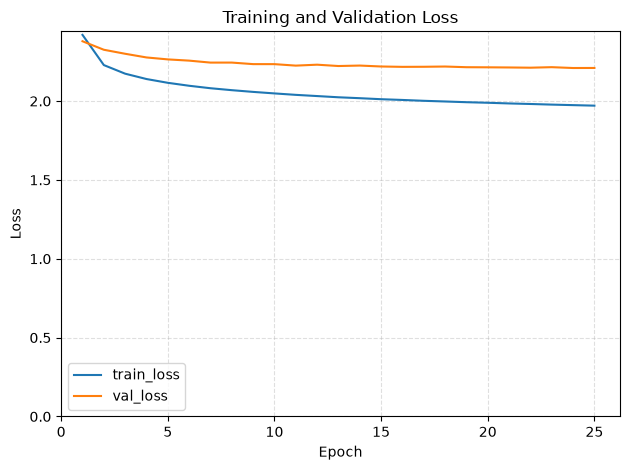

In [15]:
plot_training_history(**history)

In [16]:
def _predict_next_char(
    model: nn.Module,
    prefix: str,
    stoi: dict[str, int],
    itos: dict[int, str],
    device: str | torch.device = "cpu",
) -> str:
    """Predicts the most likely next character following a prefix.

    Args:
        model: A trained character-level RNN.
        prefix: The string of characters generated so far.
        stoi: Mapping from character/token to its id.
        itos: Mapping from id to character/token.
        device: Device to run the model on.

    Returns:
        The predicted next character (or ``<EOS>`` to stop generation).
    """
    model.eval()

    chars = ["<BOS>", *list(prefix.lower())]
    x = torch.tensor([[stoi[ch] for ch in chars]], dtype=torch.long).to(device)

    with torch.no_grad():
        logits = model(x)

    last_logits = logits[0, -1]
    probs = torch.softmax(last_logits, dim=0)

    next_id = torch.argmax(probs).item()
    next_char = itos[next_id]

    return next_char

In [17]:
ch = "hel"

print(f"input: {ch}")

while True:
    new_ch = _predict_next_char(model, ch, stoi, itos)
    if new_ch == "<EOS>":
        break
    ch += new_ch

print(f"output: {ch}")

input: hel
output: hellow
